In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("laptop_pricing_dataset_mod2.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


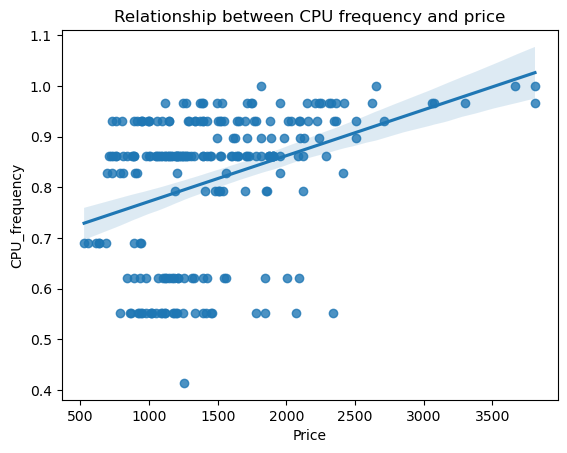

,CPU_frequency,Price
CPU_frequency,1.000000,0.366666
Price,0.366666,1.000000


In [6]:
sns.regplot(x = "Price", y = "CPU_frequency", data = df)
plt.title("Relationship between CPU frequency and price")
plt.show()

p_f_cor = df[["CPU_frequency", "Price"]].corr()
p_f_cor

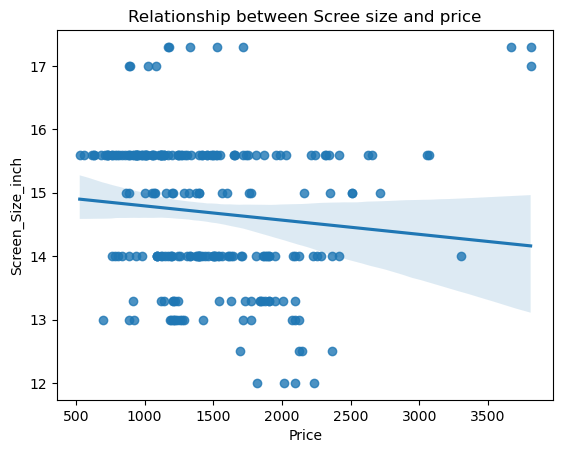

,Screen_Size_inch,Price
Screen_Size_inch,1.000000,-0.110644
Price,-0.110644,1.000000


In [7]:
sns.regplot(x = "Price", y = "Screen_Size_inch", data = df)
plt.title("Relationship between Scree size and price")
plt.show()

p_ss_cor = df[["Screen_Size_inch", "Price"]].corr()
p_ss_cor

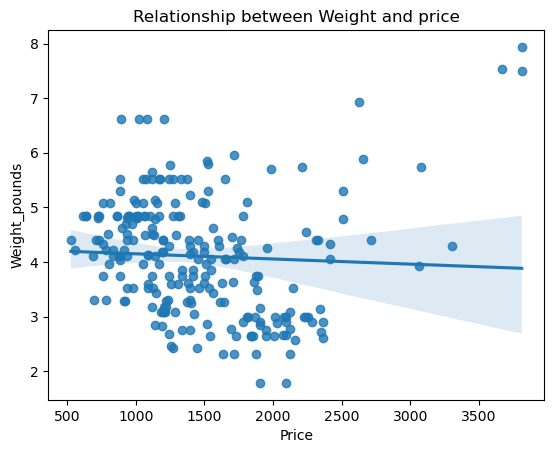

,Weight_pounds,Price
Weight_pounds,1.000000,-0.050312
Price,-0.050312,1.000000


In [8]:
sns.regplot(x = "Price", y = "Weight_pounds", data = df)
plt.title("Relationship between Weight and price")
plt.show()

p_w_cor = df[["Weight_pounds", "Price"]].corr()
p_w_cor

<Axes: xlabel='Category', ylabel='Price'>

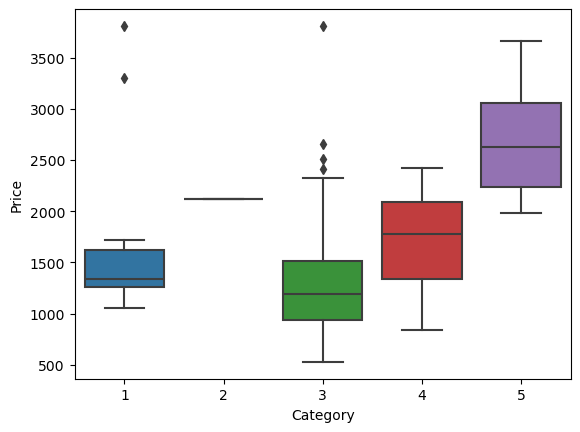

In [13]:
sns.boxplot(x = "Category", y = "Price", data = df)


In [19]:
df["Category"].unique()

array([4, 3, 1, 5, 2])

<Axes: xlabel='Manufacturer', ylabel='Price'>

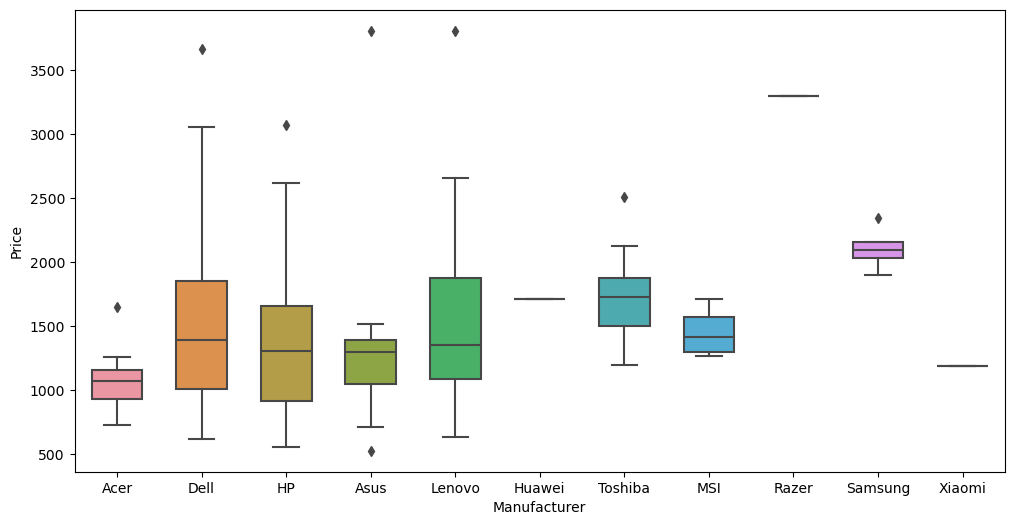

In [35]:
plt.figure(figsize = (12,6))
sns.boxplot(x = "Manufacturer", y = "Price", data = df, width = 0.6)


In [36]:
df.describe(include = "object")

,Manufacturer,Price-binned
count,238,238
unique,11,3
top,Dell,Low
freq,71,160


In [48]:
group_one = df[["GPU", "CPU_core", "Price"]]
groupby_one = group_one.groupby(["GPU", "CPU_core"], as_index = False,).mean()
groupby_one

,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


In [49]:
group_pivot = groupby_one.pivot_table(values = "Price", index = "GPU", columns = "CPU_core")
group_pivot

CPU_core,3,5,7
GPU,,,
1,769.250000,998.500000,1167.941176
2,785.076923,1462.197674,1744.621622
3,784.000000,1220.680000,1945.097561


Text(0.5, 1.0, 'GPU and CPU_core Heatmap')

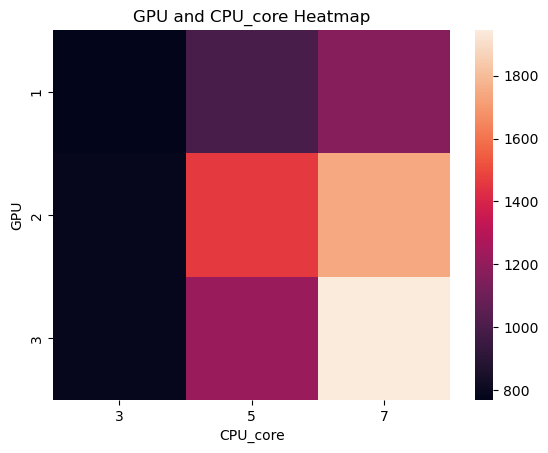

In [55]:
sns.heatmap(group_pivot)
plt.title("GPU and CPU_core Heatmap")

In [64]:
col = ["CPU_frequency", "Screen_Size_inch", "Weight_pounds", "GPU","OS", "CPU_core", "RAM_GB"]

for par in col:
    pearson_coef, p_value = stats.pearsonr(df[par], df["Price"])
    print(par)
    print(f"For {par}, the Pearson Coefficient is {pearson_coef} and the P_value {p_value}")

CPU_frequency
For CPU_frequency, the Pearson Coefficient is 0.36666555892588604 and the P_value 5.5024633507134225e-09
Screen_Size_inch
For Screen_Size_inch, the Pearson Coefficient is -0.11064420817118267 and the P_value 0.08853397846830766
Weight_pounds
For Weight_pounds, the Pearson Coefficient is -0.05031225837751549 and the P_value 0.43976938534338944
GPU
For GPU, the Pearson Coefficient is 0.2882981988881428 and the P_value 6.166949698364282e-06
OS
For OS, the Pearson Coefficient is -0.2217298011482738 and the P_value 0.0005696642559246749
CPU_core
For CPU_core, the Pearson Coefficient is 0.45939777733551157 and the P_value 7.912950127009034e-14
RAM_GB
For RAM_GB, the Pearson Coefficient is 0.5492972971857841 and the P_value 3.6815606288429613e-20
